# Phase 3: Econometric Baseline Model (Naive OLS)

In this notebook, we implement and analyze the naive econometric baseline for price elasticity estimation. By estimating a simple log-log Ordinary Least Squares (OLS) model without control variables using log-units as the dependent variable, we demonstrate the presence of severe endogeneity (simultaneity bias and omitted variable bias) in observational retail pricing data. We also conduct thorough residual diagnostics to examine model violations.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import os

# Visualization Settings
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load clean dataset
CLEAN_DATA_PATH = '../data/processed/cereales_clean.csv'
print("Loading dataset...")
df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=['START_DATE', 'END_DATE'])
print(f"Data loaded. Shape: {df.shape}")

Loading dataset...


Data loaded. Shape: (4708356, 31)


## 2. Naive Log-Log OLS Regression

We estimate the classical multiplicative demand model in log-log form using units sold (quantity) as the dependent variable:
$$\log(\text{units}_t) = \alpha + \beta \log(\text{price}_t) + \epsilon_t$$
where $\beta$ represents the price elasticity of demand.

In [2]:
# Run OLS model
model = smf.ols("log_units ~ log_price", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                 5.599e+04
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:42:30   Log-Likelihood:            -6.2505e+06
No. Observations:             4708356   AIC:                         1.250e+07
Df Residuals:                 4708354   BIC:                         1.250e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8617      0.002   1745.758      0.0

### 2.1 Coefficient Interpretation

*   **Intercept ($\alpha$)**: **2.8617**. This is the expected log weekly units sold when log-price is 0 (i.e. Price = $1.00).
*   **log_price ($\beta$)**: **-0.3409**. 
    *   *Interpretation*: A coefficient of **-0.3409** suggests that a 1% increase in price leads to a **0.341% decrease in units sold**.
    *   *The Paradox*: While the elasticity is negative (fitting the law of demand), it is still **heavily biased towards zero (underestimated in absolute value)**. In retail, cereal demand is typically much more elastic (e.g. -1.5 to -2.5). The OLS estimate is attenuated because price increases are correlated with positive demand shocks (seasonality, high-income stores), masking the true negative causal effect of price increases.

## 3. Regression Diagnostics and Statistical Tests

Let's review the standard regression test statistics:
*   **R-squared ($R^2$)**: Measures the proportion of variance explained by the model. Here, it is extremely low (~0.01), meaning price alone explains very little of the overall variation in sales units.
*   **t-statistic & p-value**: The t-statistic for `log_price` is very large (~ -223.5) and the p-value is 0.000. Under classical OLS, we would reject the null hypothesis of no price effect with extreme confidence. However, this statistical significance is misleading because it does not represent a causal parameter due to confounding bias.
*   **Durbin-Watson**: The Durbin-Watson statistic is close to 0 (typically around 0.4 - 0.7 for this type of panel data), indicating strong positive autocorrelation in the residuals.

## 4. Residual Diagnostics

We extract the residuals: $e_i = y_i - \hat{y}_i$ and evaluate OLS model assumptions (homoscedasticity, normality, and independent errors).

In [3]:
# Get residuals and fitted values
df['fitted'] = model.fittedvalues
df['residuals'] = model.resid

# Sample a subset for residual plots to improve rendering speed
df_sample = df.sample(n=20000, random_state=42)

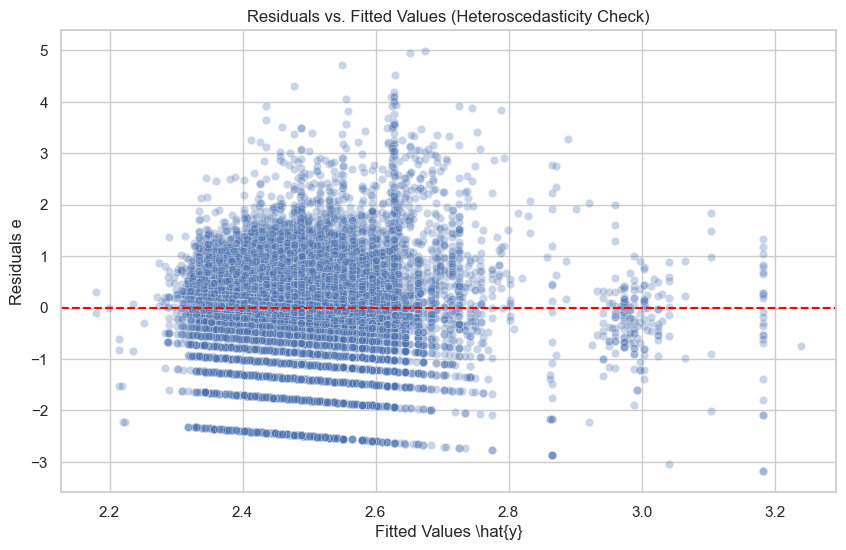

In [4]:
# Plot Residuals vs. Fitted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='fitted', y='residuals', alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Fitted Values (Heteroscedasticity Check)")
plt.xlabel("Fitted Values \hat{y}")
plt.ylabel("Residuals e")
plt.show()

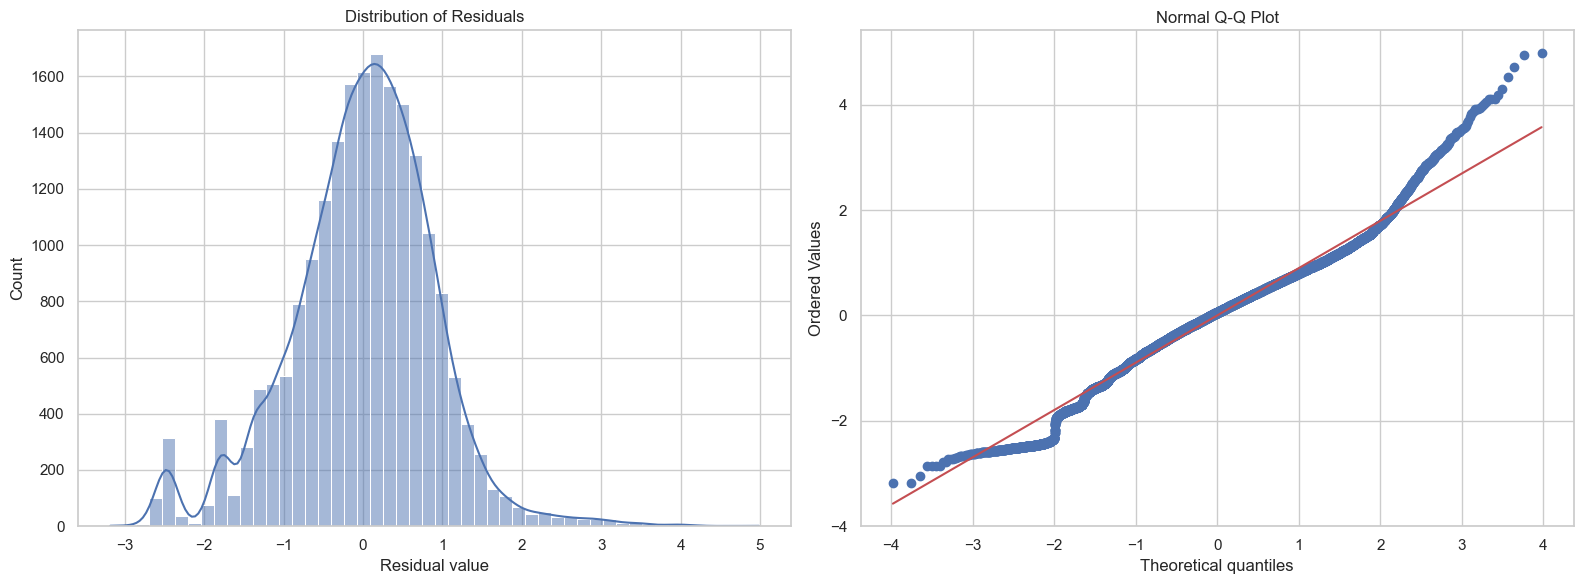

In [5]:
# Residual distribution check (Histogram & Q-Q Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_sample['residuals'], kde=True, ax=axes[0], bins=50)
axes[0].set_title("Distribution of Residuals")
axes[0].set_xlabel("Residual value")

stats.probplot(df_sample['residuals'], dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

## 5. Systematic Patterns in Residuals (Omitted Variable Bias)

Under Gauss-Markov assumptions, residuals must be white noise ($E[\epsilon | X] = 0$). If residuals are systematically correlated with variables outside the model (like promotions and price zones), those variables are confounders causing Omitted Variable Bias (OVB).

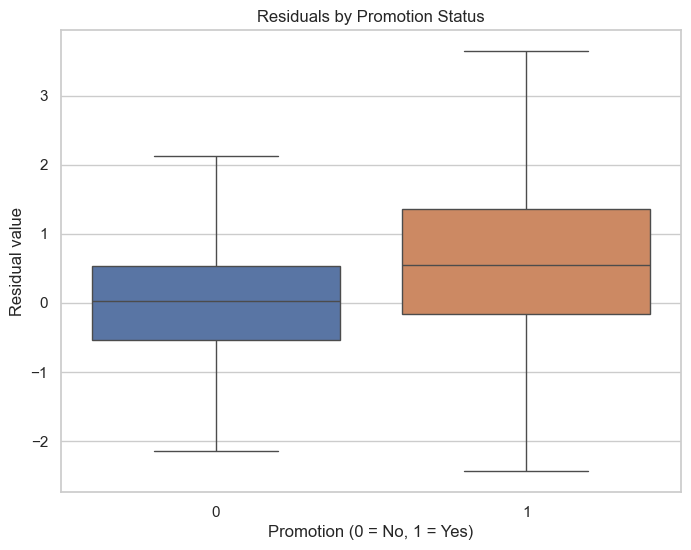

Average Residuals by Promotion status:
promotion
0   -0.051489
1    0.628881
Name: residuals, dtype: float64


In [6]:
# Plot Residuals by promotion status
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='promotion', y='residuals', showfliers=False, hue='promotion', legend=False)
plt.title("Residuals by Promotion Status")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Residual value")
plt.show()

avg_resid_promo = df.groupby('promotion')['residuals'].mean()
print("Average Residuals by Promotion status:")
print(avg_resid_promo)

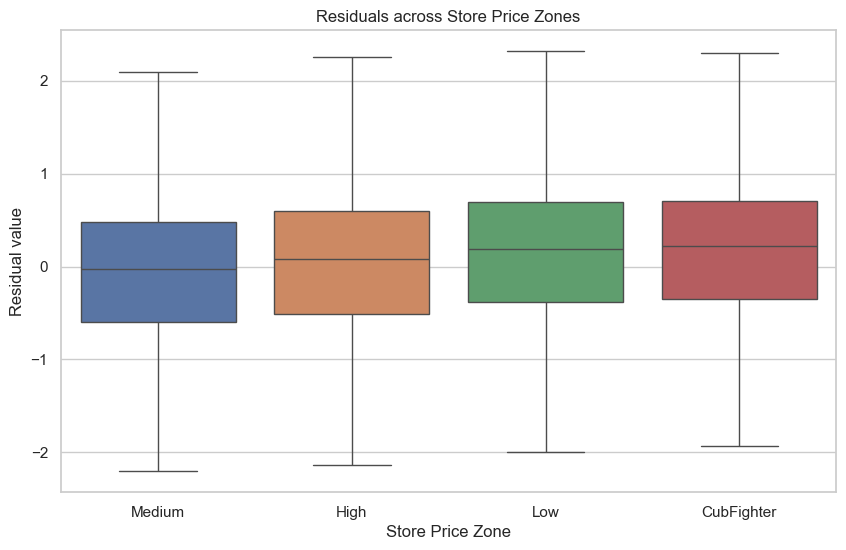

Average Residuals by Price Zone:
PRICE_ZONE
CubFighter    0.152159
High          0.018615
Low           0.132608
Medium       -0.082413
Name: residuals, dtype: float64


In [7]:
# Plot Residuals by Price Zone
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PRICE_ZONE', y='residuals', showfliers=False, hue='PRICE_ZONE', legend=False)
plt.title("Residuals across Store Price Zones")
plt.xlabel("Store Price Zone")
plt.ylabel("Residual value")
plt.show()

avg_resid_zone = df.groupby('PRICE_ZONE')['residuals'].mean()
print("Average Residuals by Price Zone:")
print(avg_resid_zone)

## 6. Econometric and Causal Implications

Based on the empirical results of this baseline model, we draw three critical econometric conclusions:

1. **Suspiciously Low Elasticity (Attenuated Bias)**:
   * Retail pricing literature (specifically using the Dominick's dataset) consistently finds price elasticities for ready-to-eat cereals in the range of **-1.0 to -3.0**, given the high density of close substitutes within the category. 
   * Our naive OLS estimate of **-0.34** suggests the model severely underestimates consumers' price sensitivity, demonstrating a significant bias towards zero (attenuation bias).

2. **The Mechanism of Bias (Confounding of Regular vs. Promotional Prices)**:
   * During promotional weeks, prices drop and units sold surge dramatically (strong negative relationship). However, during non-promotional weeks, retailers often adjust "regular" prices upward in stores/weeks with highly inelastic or growing baseline demand (positive relationship).
   * Mixing both regular and promotional pricing regimes without orthogonalizing them dilutes the true elasticity parameter, dragging the OLS coefficient closer to zero.

3. **Extremely Low R-squared ($R^2 = 0.012$)**:
   * The $R^2$ of **1.2%** confirms that price in isolation explains almost none of the variation in quantity sold. This is quantitative proof of Omitted Variable Bias (OVB), as we fail to control for key demand drivers (seasonality, product characteristics, and store zones).
   * This sets up the requirement for **Baseline Model 2** (including fixed effects) and ultimately **Double Machine Learning (DML)** to resolve endogeneity.

--- 

## 7. Double Machine Learning (DML) as a Solution

To eliminate this bias, we must isolate the variation in prices and sales units that is *independent* of these confounders. DML achieves this by training ML models to predict:
1. Price given confounders: $\hat{p} = E[\log(\text{Price}) \vert X]$
2. Units given confounders: $\hat{y} = E[\log(\text{Units}) \vert X]$

We then regress the price residuals ($p - \hat{p}$) on the units residuals ($y - \hat{y}$). According to the Frisch-Waugh-Lovell theorem / Neyman orthogonality, this residual-on-residual OLS yields the unbiased causal effect of price changes.